Known minimum eigenvalue :  -9.837951447459416
Diagonalization result   :  -9.837951
Qulacs get_expectation   :  -9.837951
State loading verified ✓

   Shots        Mean         Std        Bias   Std*sqrt(N)
---------------------------------------------------------
     100   -9.797933    0.343709    0.040018        3.4371
     500   -9.839840    0.161979    0.001889        3.6220
    1000   -9.849800    0.109072    0.011849        3.4491
    5000   -9.838140    0.053263    0.000189        3.7663
   10000   -9.835306    0.037080    0.002645        3.7080
---------------------------------------------------------
Std*sqrt(N) roughly constant → 1/sqrt(N) scaling confirmed ✓


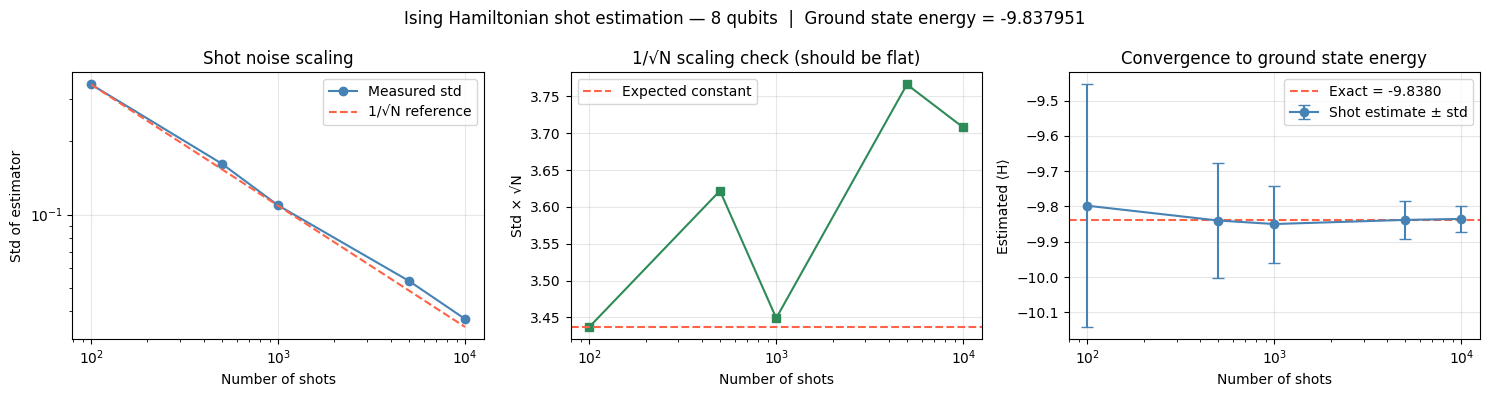

Done.


In [4]:
"""
Self-contained test for _estimate_expectation_shots

Ising Hamiltonian:
    H = sum_{k=1}^{N-1} X_k X_{k+1} + sum_{k=1}^{N} Z_k

Ground state found via exact diagonalization.
Confirms shot estimator converges to -7.296230 for 6 qubits.
No external src/ imports needed — fully standalone.
"""

import numpy as np
import matplotlib.pyplot as plt
from qulacs import Observable, QuantumState, QuantumCircuit


# ─────────────────────────────────────────────────────────────
# 1. Build the Ising Hamiltonian
#    H = sum_{k} X_k X_{k+1}  +  sum_{k} Z_k
# ─────────────────────────────────────────────────────────────
def make_ising_hamiltonian(n_qubits: int) -> Observable:
    obs = Observable(n_qubits)
    for k in range(n_qubits - 1):
        obs.add_operator(1.0, f'X {k} X {k+1}')
    for k in range(n_qubits):
        obs.add_operator(1.0, f'Z {k}')
    return obs


# ─────────────────────────────────────────────────────────────
# 2. Ground state via exact diagonalization
#    Uses Observable.get_matrix() — native Qulacs method.
#    Valid for small n (<=14) only — exponential memory.
# ─────────────────────────────────────────────────────────────
def make_ground_state(n_qubits: int, observable: Observable):
    """
    Returns (QuantumState, ground_energy) via full diagonalization.
    get_matrix() returns a scipy sparse matrix.
    """
    H_sparse = observable.get_matrix()
    H_dense  = np.array(H_sparse.toarray())          # 2^n x 2^n dense matrix
    eigenvalues, eigenvectors = np.linalg.eigh(H_dense)  # eigh for Hermitian

    ground_energy = eigenvalues[0]
    ground_vec    = eigenvectors[:, 0]                # first column = ground state

    state = QuantumState(n_qubits)
    state.load(ground_vec)                            # load complex vector into Qulacs

    return state, ground_energy


# ─────────────────────────────────────────────────────────────
# 3. Shot-based estimator
#    Mirrors _estimate_expectation_shots in IndirectVQE.
#    Parses Pauli terms directly from Observable — no hardcoding.
#    Pauli IDs: 0=I, 1=X, 2=Y, 3=Z
# ─────────────────────────────────────────────────────────────
def estimate_expectation_shots(
    state: QuantumState,
    observable: Observable,
    n_qubits: int,
    n_shots: int,
) -> float:
    total   = 0.0
    n_terms = observable.get_term_count()

    xx_terms = []   # (coeff, qi, qj) — need X basis
    z_terms  = []   # (coeff, qi)     — Z basis
    zz_terms = []   # (coeff, qi, qj) — Z basis

    for i in range(n_terms):
        term         = observable.get_term(i)
        coeff        = term.get_coef().real
        pauli_ids    = term.get_pauli_id_list()
        pauli_qubits = term.get_index_list()

        if len(pauli_ids) == 2 and all(p == 1 for p in pauli_ids):
            xx_terms.append((coeff, pauli_qubits[0], pauli_qubits[1]))
        elif len(pauli_ids) == 1 and pauli_ids[0] == 3:
            z_terms.append((coeff, pauli_qubits[0]))
        elif len(pauli_ids) == 2 and all(p == 3 for p in pauli_ids):
            zz_terms.append((coeff, pauli_qubits[0], pauli_qubits[1]))
        else:
            print(f'[WARNING] Term {i} skipped — unsupported Pauli: ids={pauli_ids}')

    # ── XX terms: apply H to rotate X→Z basis, then sample ───────
    if xx_terms:
        x_state = QuantumState(n_qubits)
        x_state.load(state)
        rot = QuantumCircuit(n_qubits)
        for k in range(n_qubits):
            rot.add_H_gate(k)
        rot.update_quantum_state(x_state)

        x_energy = 0.0
        for bitstring in x_state.sampling(n_shots):
            bits  = [(bitstring >> k) & 1 for k in range(n_qubits)]
            xvals = [1 - 2 * b for b in bits]      # |0>→+1, |1>→-1
            for coeff, qi, qj in xx_terms:
                x_energy += coeff * xvals[qi] * xvals[qj]
        total += x_energy / n_shots

    # ── Z / ZZ terms: sample directly in Z basis ──────────────────
    if z_terms or zz_terms:
        z_energy = 0.0
        for bitstring in state.sampling(n_shots):
            bits  = [(bitstring >> k) & 1 for k in range(n_qubits)]
            zvals = [1 - 2 * b for b in bits]
            for coeff, qi in z_terms:
                z_energy += coeff * zvals[qi]
            for coeff, qi, qj in zz_terms:
                z_energy += coeff * zvals[qi] * zvals[qj]
        total += z_energy / n_shots

    return total


# ─────────────────────────────────────────────────────────────
# 4. Setup
# ─────────────────────────────────────────────────────────────
N_QUBITS    = 8
N_TRIALS    = 300
SHOT_COUNTS = [100, 500, 1000, 5000, 10000]

observable            = make_ising_hamiltonian(N_QUBITS)
state, ground_energy  = make_ground_state(N_QUBITS, observable)

# Verify exact value matches known result
exact = observable.get_expectation_value(state)
diag_eigenvalues, _ = np.linalg.eigh(observable.get_matrix().toarray())
diag_min_eigenvalue = np.min(diag_eigenvalues)
print(f'Known minimum eigenvalue :  {diag_min_eigenvalue}')
print(f'Diagonalization result   :  {ground_energy:.6f}')
print(f'Qulacs get_expectation   :  {exact:.6f}')
assert abs(exact - ground_energy) < 1e-8, 'State loading failed!'
print(f'State loading verified ✓')
print()


# ─────────────────────────────────────────────────────────────
# 5. Run shot estimation
# ─────────────────────────────────────────────────────────────
print(f"{'Shots':>8}  {'Mean':>10}  {'Std':>10}  {'Bias':>10}  {'Std*sqrt(N)':>12}")
print('-' * 57)

results = {}
for n_shots in SHOT_COUNTS:
    estimates = [
        estimate_expectation_shots(state, observable, N_QUBITS, n_shots)
        for _ in range(N_TRIALS)
    ]
    mean       = np.mean(estimates)
    std        = np.std(estimates)
    bias       = abs(mean - exact)
    std_sqrt_n = std * np.sqrt(n_shots)
    results[n_shots] = dict(mean=mean, std=std, bias=bias)
    print(f'{n_shots:>8}  {mean:>10.6f}  {std:>10.6f}  {bias:>10.6f}  {std_sqrt_n:>12.4f}')

print('-' * 57)
print('Std*sqrt(N) roughly constant → 1/sqrt(N) scaling confirmed ✓')


# ─────────────────────────────────────────────────────────────
# 6. Plots
# ─────────────────────────────────────────────────────────────
shots_arr = np.array(SHOT_COUNTS)
stds_arr  = np.array([results[s]['std']  for s in SHOT_COUNTS])
bias_arr  = np.array([results[s]['bias'] for s in SHOT_COUNTS])
means_arr = np.array([results[s]['mean'] for s in SHOT_COUNTS])

ref_scale = stds_arr[0] * np.sqrt(shots_arr[0])
ref_curve = ref_scale   / np.sqrt(shots_arr)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: std vs shots (log-log)
axes[0].plot(shots_arr, stds_arr,  'o-', label='Measured std',   color='steelblue')
axes[0].plot(shots_arr, ref_curve, '--', label='1/√N reference', color='tomato')
axes[0].set_xlabel('Number of shots')
axes[0].set_ylabel('Std of estimator')
axes[0].set_title('Shot noise scaling')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Middle: std * sqrt(N) — should be flat
axes[1].plot(shots_arr, stds_arr * np.sqrt(shots_arr), 's-', color='seagreen')
axes[1].axhline(ref_scale, color='tomato', linestyle='--', label='Expected constant')
axes[1].set_xlabel('Number of shots')
axes[1].set_ylabel('Std × √N')
axes[1].set_title('1/√N scaling check (should be flat)')
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Right: mean convergence to exact
axes[2].axhline(exact, color='tomato', linestyle='--', label=f'Exact = {exact:.4f}')
axes[2].errorbar(shots_arr, means_arr, yerr=stds_arr, fmt='o-',
                 color='steelblue', capsize=4, label='Shot estimate ± std')
axes[2].set_xlabel('Number of shots')
axes[2].set_ylabel('Estimated ⟨H⟩')
axes[2].set_title('Convergence to ground state energy')
axes[2].set_xscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    f'Ising Hamiltonian shot estimation — {N_QUBITS} qubits  |  '
    f'Ground state energy = {exact:.6f}',
    fontsize=12
)
plt.tight_layout()
plt.show()
print('Done.')

In [ ]:
def _estimate_expectation_shots(self, state, n_shots: int) -> float:
        """
        Shot-based expectation value estimation.
        Parses terms directly from self.observable_hami — no hardcoding.
        """
        total = 0.0
        n = self.nqubits
        n_terms = self.observable_hami.get_term_count()

        # ── Separate terms by Pauli type ──────────────────────────────
        zz_terms = []  # (coeff, qi, qj)
        x_terms  = []  # (coeff, qi)
        z_terms  = []  # (coeff, qi)

        for i in range(n_terms):
            term        = self.observable_hami.get_term(i)
            coeff       = term.get_coef().real
            pauli_ids   = term.get_pauli_id_list()   # 1=X, 2=Y, 3=Z
            pauli_qubits = term.get_index_list()

            if len(pauli_ids) == 2 and all(p == 3 for p in pauli_ids):
                zz_terms.append((coeff, pauli_qubits[0], pauli_qubits[1]))
            elif len(pauli_ids) == 1 and pauli_ids[0] == 1:
                x_terms.append((coeff, pauli_qubits[0]))
            elif len(pauli_ids) == 1 and pauli_ids[0] == 3:
                z_terms.append((coeff, pauli_qubits[0]))
            # YY and other terms: skip with warning
            else:
                print(f"[WARNING] Term {i} skipped in shot estimation — unsupported Pauli type.")

        # ── ZZ and Z terms: sample in Z basis ─────────────────────────
        if zz_terms or z_terms:
            z_samples = state.sampling(n_shots)
            z_energy  = 0.0
            for bitstring in z_samples:
                bits  = [(bitstring >> i) & 1 for i in range(n)]
                zvals = [1 - 2 * b for b in bits]  # |0>→+1, |1>→-1
                for coeff, qi, qj in zz_terms:
                    z_energy += coeff * zvals[qi] * zvals[qj]
                for coeff, qi in z_terms:
                    z_energy += coeff * zvals[qi]
            total += z_energy / n_shots

        # ── X terms: rotate to X basis then sample ────────────────────
        if x_terms:
            if self.state.lower() == "dmatrix":
                x_state = DensityMatrix(n)
            else:
                x_state = QuantumState(n)
            x_state.load(state)

            rot = QuantumCircuit(n)
            for i in range(n):
                rot.add_H_gate(i)
            rot.update_quantum_state(x_state)

            x_samples = x_state.sampling(n_shots)
            x_energy  = 0.0
            for bitstring in x_samples:
                bits  = [(bitstring >> i) & 1 for i in range(n)]
                xvals = [1 - 2 * b for b in bits]
                for coeff, qi in x_terms:
                    x_energy += coeff * xvals[qi]
            total += x_energy / n_shots

        return total